# Supplementary: Player strategies

How `shapiq.vision.players` partitions an image into Shapley *players*. Pixel strategies return `(n_players, H, W)` masks; latent strategies define ViT token groups.

Main tutorial: `tutorial_01_player_masker_strategies.ipynb` combines players with masking and models.

## Setup

In [4]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision import transforms

import shapiq.vision as _vision_module

# Bundled sample image (same as tutorial_03) — no network access required
DOG_PATH = Path(_vision_module.__file__).parent / "dog.png"
assert DOG_PATH.exists(), f"dog.png not found at {DOG_PATH}"

pil_224 = transforms.Compose(
    [transforms.Resize(256), transforms.CenterCrop(224)]
)(Image.open(DOG_PATH).convert("RGB"))
image = np.asarray(pil_224)
print("image shape:", image.shape)


image shape: (224, 224, 3)


## Pixel strategies on one image

- `GridStrategy` — regular rows×cols tiles (good for quick experiments)
- `SuperpixelStrategy` — SLIC regions (default on CNN / CLIP architectures)
- `CustomMasksStrategy` — arbitrary user masks (overlaps allowed)

GridStrategy 3×3 (9, 224, 224)


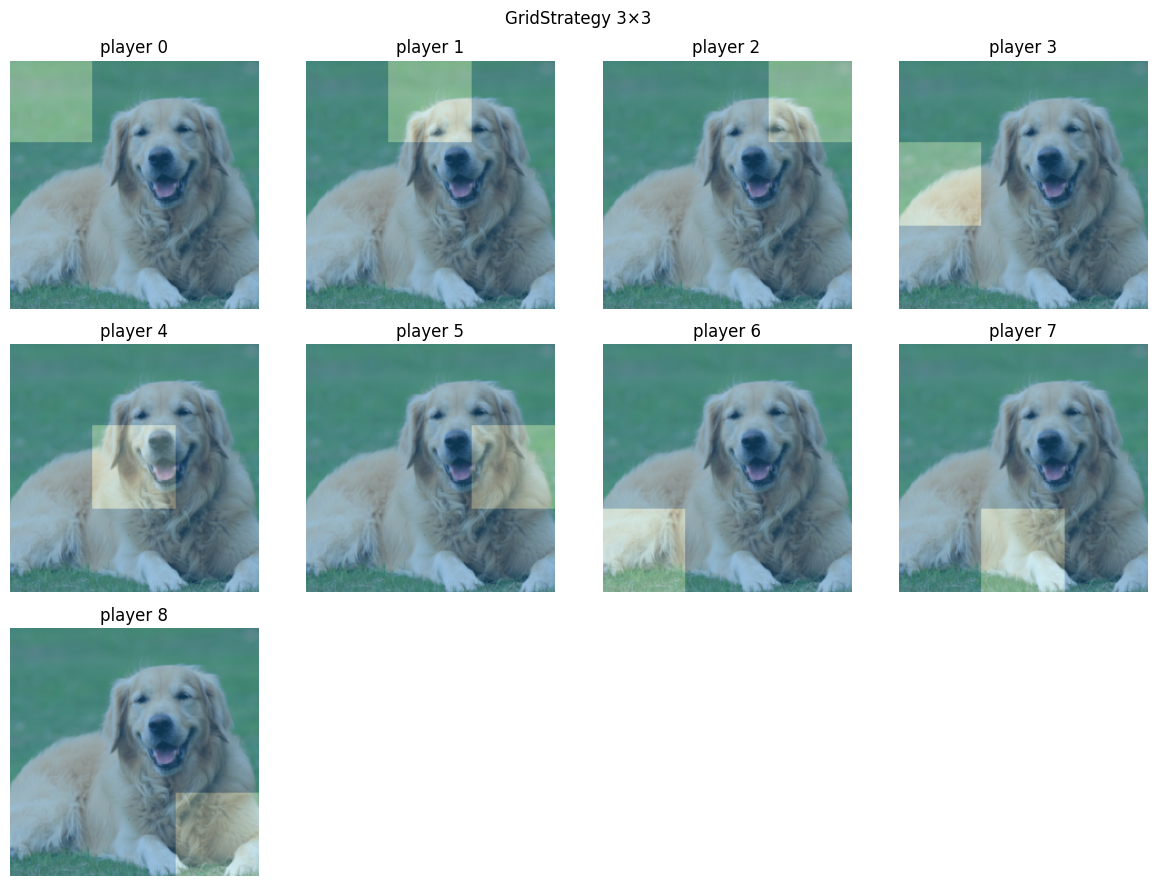

SuperpixelStrategy (9 segments) (9, 224, 224)


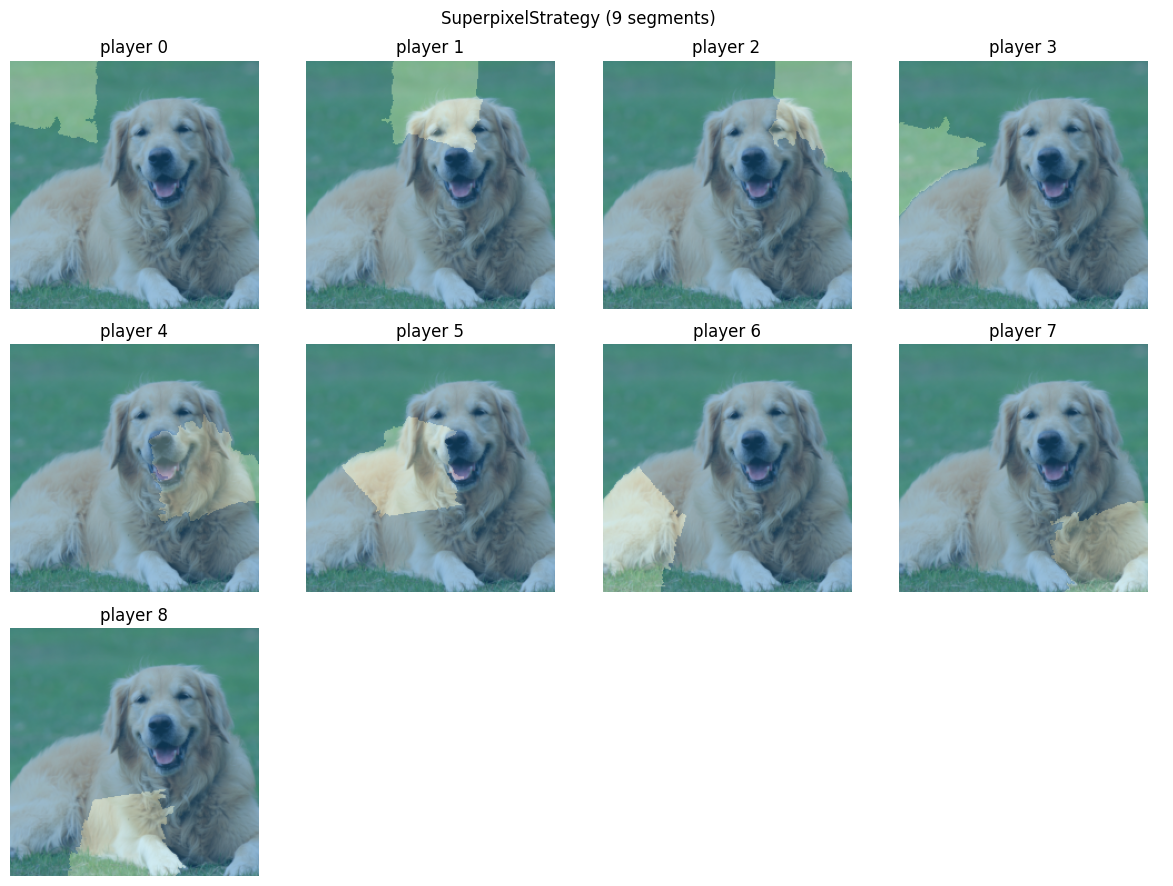

CustomMasksStrategy (3 masks) (3, 224, 224)


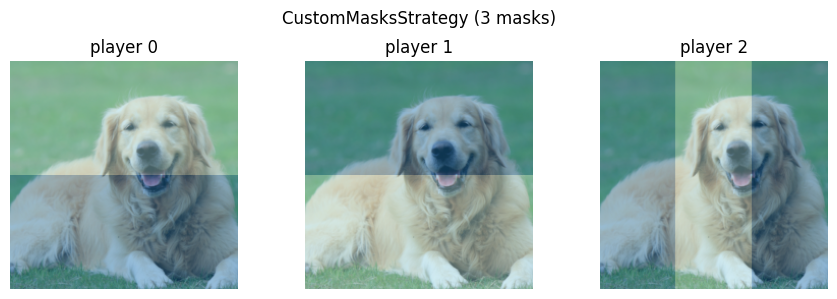

In [5]:
from shapiq.vision.players import CustomMasksStrategy, GridStrategy, SuperpixelStrategy


def show_masks(masks, title):
    n = masks.shape[0]
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.atleast_1d(axes).ravel()
    for i in range(n):
        axes[i].imshow(image)
        axes[i].imshow(masks[i], alpha=0.45, cmap="tab20", vmin=0, vmax=1)
        axes[i].set_title(f"player {i}")
        axes[i].axis("off")
    for j in range(n, len(axes)):
        axes[j].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


grid = GridStrategy(rows=3, cols=3)
superpixel = SuperpixelStrategy(n_segments=9)

h, w = image.shape[:2]
custom = np.zeros((3, h, w), dtype=bool)
custom[0, : h // 2, :] = True  # top half
custom[1, h // 2 :, :] = True  # bottom half
custom[2, :, w // 3 : 2 * w // 3] = True  # centre strip (overlaps)
custom_strategy = CustomMasksStrategy(custom)

strategies = [
    ("GridStrategy 3×3", grid.get_masks(image)),
    ("SuperpixelStrategy (9 segments)", superpixel.get_masks(image)),
    ("CustomMasksStrategy (3 masks)", custom_strategy.get_masks(image)),
]
for title, masks in strategies:
    print(title, masks.shape)
    show_masks(masks, title)

## Latent `PatchStrategy` for ViT

Patch players are macro-regions on the token grid, not painted on pixels. The heatmap marks which tokens belong to each player when only player 0 is present.

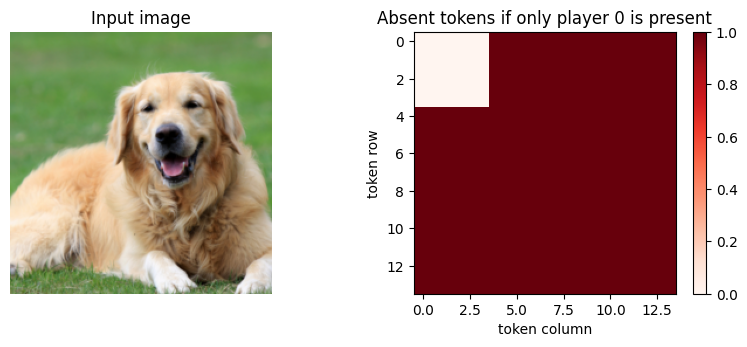

n_players=9, grid_size=14


In [6]:
from shapiq.vision.players import PatchStrategy

side = 3
n_players = side * side
grid_size = 14  # ViT-B/16 on 224×224
patch = PatchStrategy(grid_size=grid_size, n_players=n_players)

coalition = np.zeros(n_players, dtype=bool)
coalition[0] = True
latent_mask = patch.get_latent_mask(coalition).reshape(grid_size, grid_size).numpy()

fig, ax = plt.subplots(1, 2, figsize=(8, 3.5))
ax[0].imshow(image)
ax[0].set_title("Input image")
ax[0].axis("off")
im = ax[1].imshow(latent_mask, cmap="Reds", vmin=0, vmax=1)
ax[1].set_title("Absent tokens if only player 0 is present")
ax[1].set_xlabel("token column")
ax[1].set_ylabel("token row")
fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout()
plt.show()

print(f"n_players={patch.n_players}, grid_size={grid_size}")